# Semi-discrete Monge maps

This notebook generates `fig:monge-semidiscrete-maps`.  It illustrates the semi-discrete Monge situation

$$
\alpha \ll \mathcal L^2, \qquad \beta=\frac1m\sum_{j=1}^m\delta_{y_j},
$$

where the optimal map is piecewise constant: each Laguerre cell is sent to one target atom.  The two panels are deliberately simple.  The first transports a continuous Gaussian density on the left to a 15-point empirical Gaussian on the right.  The second transports a two-component Gaussian mixture, with modes on both sides, to a 20-point empirical Gaussian in the middle.  The target atoms are generated as regularized Gaussian discretizations rather than purely random samples, and colors are tied to the horizontal position of the target atoms with a small random perturbation.  This makes it possible to match each atom with the Laguerre cell that is transported to it.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgb

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED,
    BLUE,
    VIOLET,
    interp_color,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

## Semi-discrete solver

The computation is intentionally lightweight.  The source density is sampled on a regular grid, and we perform gradient ascent on the semi-discrete dual weights.  At convergence, the grid mass of each Laguerre cell is close to the prescribed target mass $1/m$.

In [2]:
NAME = "monge-semidiscrete-maps"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
rng = np.random.default_rng(1739)


def gaussian_2d(grid, mean, cov):
    """Evaluate a correctly scaled two-dimensional Gaussian density."""
    diff = grid - np.asarray(mean)
    inv = np.linalg.inv(cov)
    quad = np.einsum("...i,ij,...j->...", diff, inv, diff)
    return np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))


def regularized_gaussian_sites(mean, cov, m, seed):
    """Low-discrepancy-looking Gaussian atoms with a small random perturbation."""
    local = np.random.default_rng(seed)
    golden = np.pi * (3.0 - np.sqrt(5.0))
    k = np.arange(m)
    u = (k + 0.55) / (m + 0.15)
    radii = np.sqrt(-2.0 * np.log(np.clip(1.0 - u, 1e-6, 1.0)))
    angles = golden * k + local.normal(scale=0.10, size=m)
    local.shuffle(radii)
    z = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])
    z += local.normal(scale=0.045, size=z.shape)
    return np.asarray(mean) + z @ np.linalg.cholesky(np.asarray(cov)).T


def palette_from_x(sites, seed):
    """Map horizontal position to a red-violet-blue palette, with mild jitter."""
    local = np.random.default_rng(seed)
    x = sites[:, 0]
    t = (x - x.min()) / max(x.max() - x.min(), 1e-12)
    colors = []
    for u in t:
        if u < 0.5:
            base = np.array(interp_color(u / 0.5, RED, VIOLET))
        else:
            base = np.array(interp_color((u - 0.5) / 0.5, VIOLET, BLUE))
        jitter = local.normal(scale=0.032, size=3)
        colors.append(tuple(np.clip(base + jitter, 0.06, 0.94)))
    return colors


def solve_weights(grid, rho, sites, beta, n_iter=1250):
    """Approximate semi-discrete weights by grid-based semi-dual ascent."""
    cost = ((grid[..., None, 0] - sites[:, 0]) ** 2 + (grid[..., None, 1] - sites[:, 1]) ** 2)
    gamma = np.zeros(len(sites))
    velocity = np.zeros_like(gamma)
    for it in range(n_iter):
        labels = np.argmin(cost - gamma[None, None, :], axis=2)
        masses = np.array([(rho * (labels == j)).sum() for j in range(len(sites))])
        step = 1.25 / (it + 12.0) ** 0.58
        velocity = 0.72 * velocity + step * (beta - masses)
        gamma += velocity
        gamma -= gamma.mean()
    labels = np.argmin(cost - gamma[None, None, :], axis=2)
    masses = np.array([(rho * (labels == j)).sum() for j in range(len(sites))])
    return gamma, labels, masses


def cell_centroids(grid, rho, labels, m):
    """Return source barycenters of the Laguerre cells for drawing transport rays."""
    centroids = []
    for j in range(m):
        w = rho * (labels == j)
        mass = w.sum()
        if mass <= 0:
            centroids.append(np.array([np.nan, np.nan]))
        else:
            centroids.append((grid * w[..., None]).sum(axis=(0, 1)) / mass)
    return np.array(centroids)


## Two source/target configurations

The first example is a single Gaussian-to-Gaussian empirical target.  The second uses a two-mode source density and a central empirical Gaussian target, which makes it clear that the semi-discrete map can collapse mass from separated regions onto a finite cloud of atoms.

In [3]:
def make_case(kind):
    if kind == "single":
        xlim = (-2.55, 2.65)
        ylim = (-1.55, 1.55)
        gx = np.linspace(*xlim, 270)
        gy = np.linspace(*ylim, 165)
        GX, GY = np.meshgrid(gx, gy)
        grid = np.stack([GX, GY], axis=-1)
        rho = gaussian_2d(grid, [-1.12, 0.02], [[0.30, 0.06], [0.06, 0.36]])
        m = 15
        sites = regularized_gaussian_sites([1.20, 0.03], [[0.20, -0.025], [-0.025, 0.30]], m, 301)
        sites[:, 0] = np.clip(sites[:, 0], 0.42, 2.02)
        sites[:, 1] = np.clip(sites[:, 1], -1.08, 1.08)
        filename = "gaussian-to-discrete.pdf"
        color_seed = 101
    elif kind == "mixture":
        xlim = (-2.75, 2.75)
        ylim = (-1.65, 1.65)
        gx = np.linspace(*xlim, 290)
        gy = np.linspace(*ylim, 175)
        GX, GY = np.meshgrid(gx, gy)
        grid = np.stack([GX, GY], axis=-1)
        rho = (
            0.52 * gaussian_2d(grid, [-1.32, 0.42], [[0.20, 0.04], [0.04, 0.23]])
            + 0.48 * gaussian_2d(grid, [1.36, -0.38], [[0.23, -0.05], [-0.05, 0.20]])
        )
        m = 20
        sites = regularized_gaussian_sites([0.0, 0.0], [[0.20, 0.02], [0.02, 0.27]], m, 401)
        sites[:, 0] = np.clip(sites[:, 0], -0.88, 0.88)
        sites[:, 1] = np.clip(sites[:, 1], -1.02, 1.02)
        filename = "mixture-to-discrete.pdf"
        color_seed = 211
    else:
        raise ValueError(kind)

    rho = rho / rho.sum()
    beta = np.full(m, 1.0 / m)
    gamma, labels, masses = solve_weights(grid, rho, sites, beta)
    centroids = cell_centroids(grid, rho, labels, m)
    return {
        "kind": kind,
        "xlim": xlim,
        "ylim": ylim,
        "GX": GX,
        "GY": GY,
        "grid": grid,
        "rho": rho,
        "sites": sites,
        "labels": labels,
        "beta": beta,
        "masses": masses,
        "centroids": centroids,
        "filename": filename,
        "colors": palette_from_x(sites, color_seed),
    }


cases = [make_case("single"), make_case("mixture")]
[(case["kind"], float(np.abs(case["masses"] - case["beta"]).sum())) for case in cases]


[('single', 0.0006714220555464057), ('mixture', 0.000524282605020833)]

## Rendering

The colored region is the part of the source support where the density is not negligible.  Thin white curves mark Laguerre-cell boundaries, red contours show the continuous source density, colored circles are the target atoms, and faint colored segments connect each cell barycenter to the atom receiving that cell's mass.


In [4]:
def draw_case(ax, case):
    sites = case["sites"]
    labels = case["labels"]
    rho = case["rho"]
    colors = case["colors"]
    m = len(sites)
    cmap = ListedColormap(colors)

    support = rho > 0.0032 * rho.max()
    masked_labels = np.ma.array(labels, mask=~support)
    ax.pcolormesh(
        case["GX"],
        case["GY"],
        masked_labels,
        cmap=cmap,
        shading="nearest",
        alpha=0.50,
        rasterized=True,
        zorder=1,
    )
    ax.contour(
        case["GX"],
        case["GY"],
        masked_labels,
        levels=np.arange(m + 1) - 0.5,
        colors="white",
        linewidths=0.46,
        alpha=0.92,
        zorder=2,
    )
    levels = np.quantile(rho[rho > 0], [0.76, 0.84, 0.91, 0.965, 0.988])
    ax.contour(
        case["GX"],
        case["GY"],
        rho,
        levels=levels,
        colors=[RED],
        linewidths=[0.45, 0.48, 0.52, 0.58, 0.62],
        alpha=0.52,
        zorder=3,
    )

    segments = []
    segment_colors = []
    for j, (centroid, site) in enumerate(zip(case["centroids"], sites)):
        if np.all(np.isfinite(centroid)):
            segments.append([centroid, site])
            segment_colors.append((*to_rgb(colors[j]), 0.48))
    ax.add_collection(LineCollection(segments, colors=segment_colors, linewidths=0.58, zorder=4))

    ax.scatter(sites[:, 0], sites[:, 1], s=33, marker="o", c="white", edgecolors="none", zorder=5)
    ax.scatter(sites[:, 0], sites[:, 1], s=23, marker="o", c=colors, edgecolors="#202020", linewidths=0.24, zorder=6)

    ax.set_xlim(*case["xlim"])
    ax.set_ylim(*case["ylim"])
    ax.set_aspect("equal")
    remove_axes(ax)


for case in cases:
    fig, ax = plt.subplots(figsize=(3.28, 2.05))
    draw_case(ax, case)
    save_pdf(fig, OUT / case["filename"], pad_inches=0.035)
    plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(6.35, 2.0))
for ax, case in zip(axes, cases):
    draw_case(ax, case)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.035)
THUMB.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(THUMB, dpi=170, bbox_inches="tight", pad_inches=0.018)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

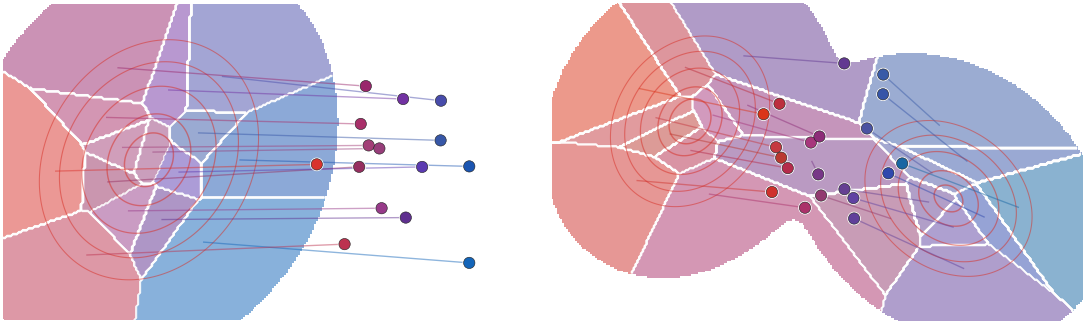

In [5]:
from IPython.display import Image, display

_thumb = Path("thumbnails/monge-semidiscrete-maps.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-semidiscrete-maps.png")
display(Image(filename=str(_thumb)))